# Sesión 19: Taller de Reducción de Dimensionalidad (PCA y t-SNE)

**Objetivos:**
-   Entender por qué demasiadas dimensiones ("features") puede ser un problema (la "maldición de la dimensionalidad").
-   Aprender la intuición de **PCA** para comprimir datos y preservar la varianza global.
-   Aprender la intuición de **t-SNE** para crear visualizaciones de alta calidad que preservan los "vecindarios" de los datos.
-   Comparar visualmente los resultados de ambas técnicas en un dataset de alta dimensión.

## 1. El Problema: ¿Cómo Dibujamos 64 Dimensiones?

Imagina que tienes datos con 2 o 3 características. ¡Fácil! Haces un scatter plot. Pero, ¿qué pasa si tienes 64? Nuestro cerebro no puede visualizar más allá de 3 dimensiones. Esto es la **maldición de la dimensionalidad**.

Hoy trabajaremos con un dataset de imágenes de dígitos escritos a mano. Cada imagen es de 8x8 píxeles, lo que significa que cada dígito está descrito por **64 características**.

**Tu primera tarea:** Carga el dataset y comprueba su dimensionalidad.

In [1]:
# --- Imports y Carga del Dataset ---
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Cargar los datos
digits = load_digits()
X = digits.data
y = digits.target

print(f"Forma de nuestros datos (X): {X.shape}")
print(f"Cada una de las {X.shape[0]} imágenes tiene {X.shape[1]} características (píxeles).")

Forma de nuestros datos (X): (1797, 64)
Cada una de las 1797 imágenes tiene 64 características (píxeles).


## 2. PCA: Encontrando la "Sombra" más Informativa

* **Intuición:** PCA (Análisis de Componentes Principales) busca las direcciones en los datos donde hay más **variación**. Luego, proyecta los datos sobre estas nuevas direcciones (los "componentes principales") para crear una versión "aplastada" o una "sombra" de los datos originales.
* **Uso:** Es genial para preprocesamiento y compresión de datos.

**Tu tarea:** Aplica PCA para reducir las 64 dimensiones a solo 2. Luego, visualiza el resultado coloreando cada punto por su dígito real.

Forma de los datos después de PCA: (1797, 2)


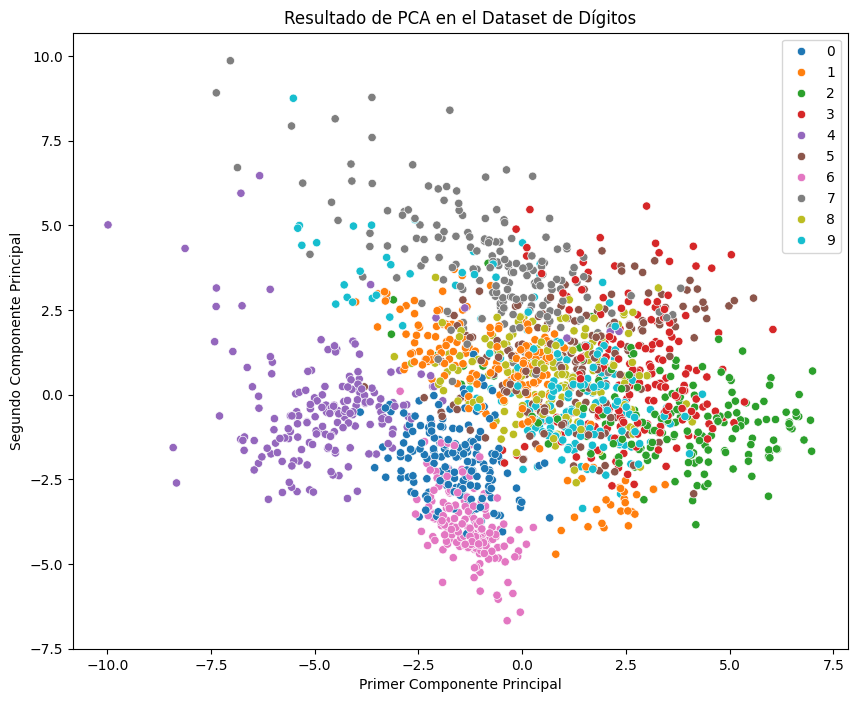

In [2]:
# --- Aplicando y Visualizando PCA ---
# Primero, escalamos los datos, es una buena práctica para PCA
X_scaled = StandardScaler().fit_transform(X)

# 1. Aplicar PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Forma de los datos después de PCA: {X_pca.shape}")

# 2. Visualizar el resultado de PCA
plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='tab10', legend='full')
plt.title('Resultado de PCA en el Dataset de Dígitos')
plt.xlabel('Primer Componente Principal')
plt.ylabel('Segundo Componente Principal')
plt.show()

## 3. t-SNE: Creando el "Mapa de Vecindarios"

* **Intuición:** t-SNE (t-Distributed Stochastic Neighbor Embedding) tiene un solo objetivo: crear una **visualización bonita** en 2D o 3D. No le importa la estructura global, solo se obsesiona con una cosa: que los puntos que eran "vecinos" cercanos en 64 dimensiones, sigan siendo vecinos cercanos en 2 dimensiones.
* **Uso:** ¡Exclusivamente para visualización y exploración!

**⚠️ Advertencia Crucial:** Las distancias entre los clústeres en un gráfico t-SNE **no significan nada**. Solo la agrupación local (los "vecindarios") es relevante.

**Tu tarea:** Aplica t-SNE a los mismos datos escalados y visualiza el resultado.

Calculando t-SNE... esto puede tardar un minuto.
Forma de los datos después de t-SNE: (1797, 2)


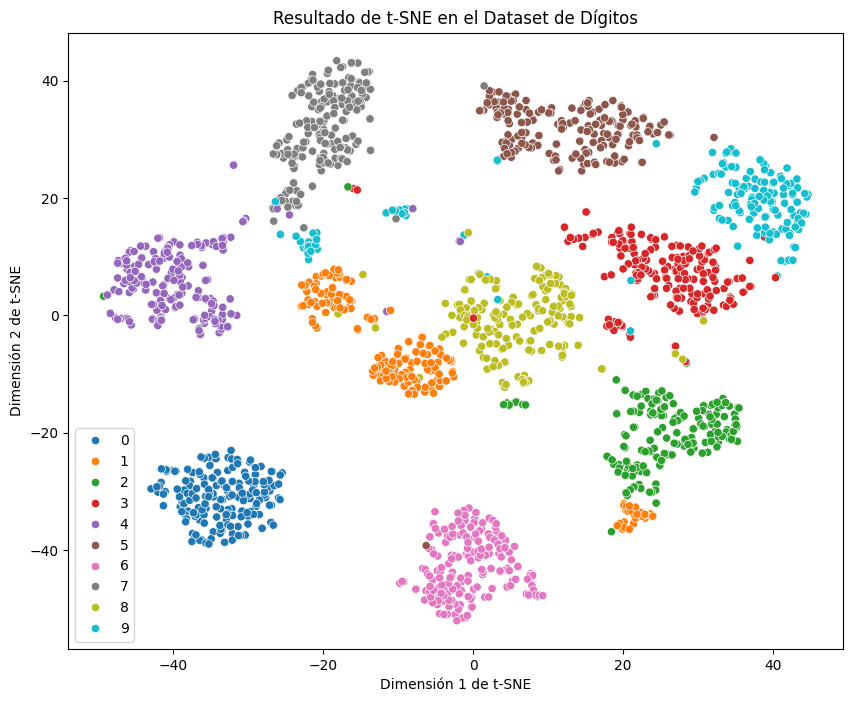

In [3]:
# --- Aplicando y Visualizando t-SNE ---
# t-SNE puede ser lento, ¡ten paciencia!
print("Calculando t-SNE... esto puede tardar un minuto.")

# 1. Aplicar t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

print(f"Forma de los datos después de t-SNE: {X_tsne.shape}")

# 2. Visualizar el resultado de t-SNE
plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y, palette='tab10', legend='full')
plt.title('Resultado de t-SNE en el Dataset de Dígitos')
plt.xlabel('Dimensión 1 de t-SNE')
plt.ylabel('Dimensión 2 de t-SNE')
plt.show()

---
## Ejercicio 1: Explorando Fashion-MNIST

**Contexto:** Ahora te toca a ti. Vamos a usar un dataset un poco más complejo: **Fashion-MNIST**. Contiene 70,000 imágenes de 28x28 píxeles (784 dimensiones) de 10 tipos de prendas de vestir.

**Tu Reto:**
1.  **Carga** el dataset Fashion-MNIST usando el código proporcionado. Como es grande, usaremos solo una muestra para que t-SNE no tarde demasiado.
2.  Aplica **PCA** y **t-SNE** para reducir las 784 dimensiones a solo 2.
3.  Crea una **figura con dos subplots** para comparar el resultado de PCA (izquierda) y t-SNE (derecha).
4.  **Responde a las siguientes preguntas de reflexión**:
    * ¿Qué técnica, PCA o t-SNE, separó mejor las prendas de vestir? ¿Por qué crees que es?
    * Observando tu gráfico de t-SNE, ¿hay algunas prendas que aparecen muy juntas o mezcladas? ¿Qué te dice esto sobre cómo se ven esas prendas? (Ej. ¿se parecen las camisetas y las camisas?).
    * Describe una situación en la que preferirías usar PCA en lugar de t-SNE, y por qué.

In [4]:
# --- ESPACIO PARA EL RETO PARA CASA ---
from sklearn.datasets import fetch_openml

# 1. Cargar Fashion-MNIST
print("Cargando Fashion-MNIST...")
X_fashion, y_fashion = fetch_openml('Fashion-MNIST', version=1, return_X_y=True)
print("Dataset cargado.")

# Para que el ejercicio sea más rápido, tomaremos una muestra aleatoria de 5000 imágenes
np.random.seed(42)
sample_indices = np.random.choice(X_fashion.shape[0], 5000, replace=False)
X_sample = X_fashion.iloc[sample_indices]
y_sample = y_fashion.iloc[sample_indices]

# Escalar los datos de la muestra
X_sample_scaled = StandardScaler().fit_transform(X_sample)



Cargando Fashion-MNIST...
Dataset cargado.


Forma de los datos después de PCA: (5000, 2)


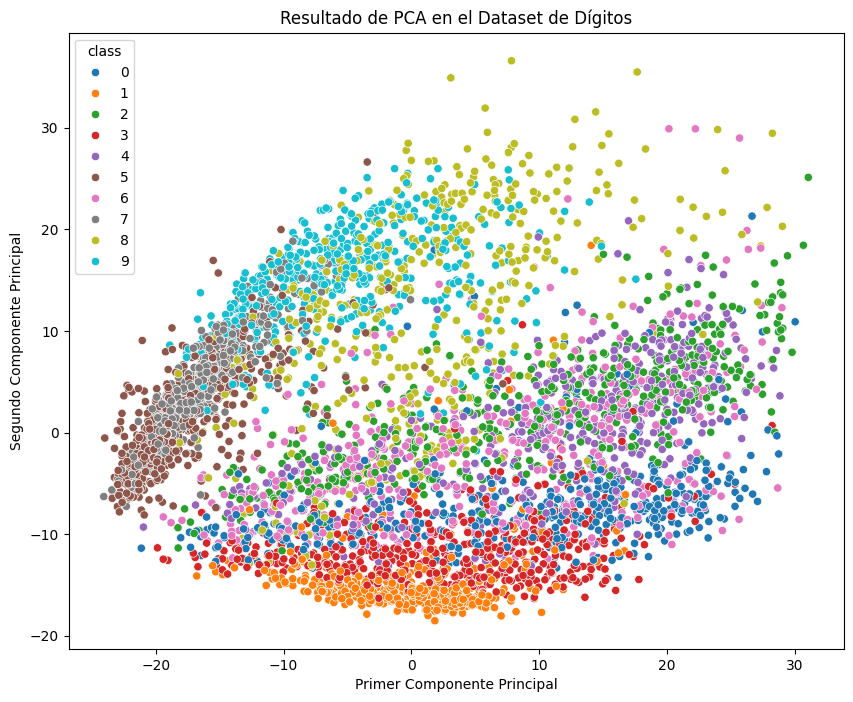

In [5]:
# 2. Aplicar PCA y t-SNE

# 1. Aplicar PCA
pca = PCA(n_components=2, random_state=42)
X_sample_pca = pca.fit_transform(X_sample_scaled)

print(f"Forma de los datos después de PCA: {X_sample_pca.shape}")

# 2. Visualizar el resultado de PCA
plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_sample_pca[:, 0], y=X_sample_pca[:, 1], hue=y_sample, palette='tab10', legend='full')
plt.title('Resultado de PCA en el Dataset de Dígitos')
plt.xlabel('Primer Componente Principal')
plt.ylabel('Segundo Componente Principal')
plt.show()

Calculando t-SNE... esto puede tardar un minuto.
Forma de los datos después de t-SNE: (5000, 2)


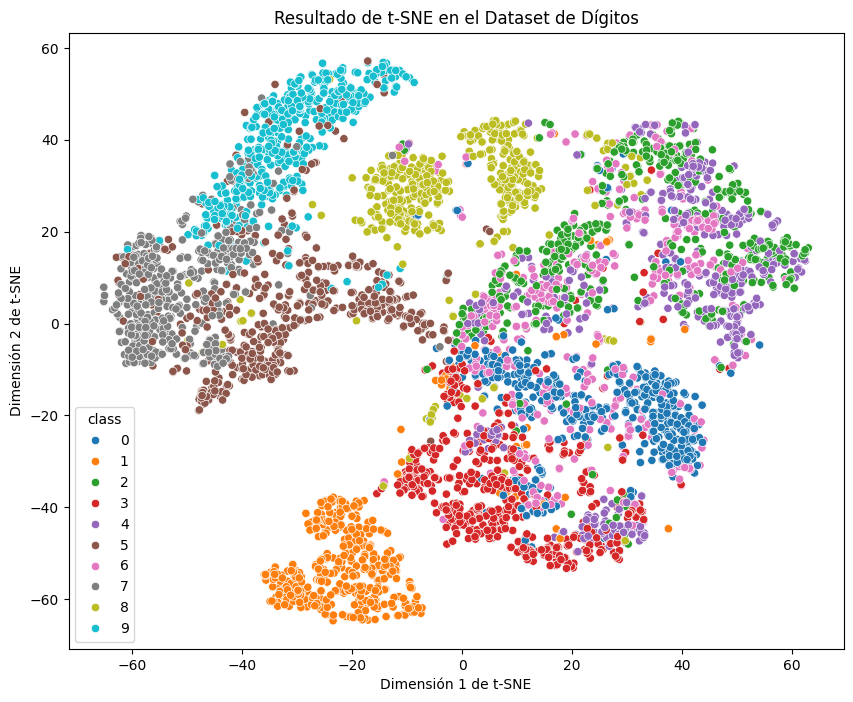

In [7]:

# --- Aplicando y Visualizando t-SNE ---
# t-SNE puede ser lento, ¡ten paciencia!
print("Calculando t-SNE... esto puede tardar un minuto.")

# 1. Aplicar t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_sample_tsne = tsne.fit_transform(X_sample_scaled)

print(f"Forma de los datos después de t-SNE: {X_sample_tsne.shape}")

# 2. Visualizar el resultado de t-SNE
plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_sample_tsne[:, 0], y=X_sample_tsne[:, 1], hue=y_sample, palette='tab10', legend='full')
plt.title('Resultado de t-SNE en el Dataset de Dígitos')
plt.xlabel('Dimensión 1 de t-SNE')
plt.ylabel('Dimensión 2 de t-SNE')
plt.show()

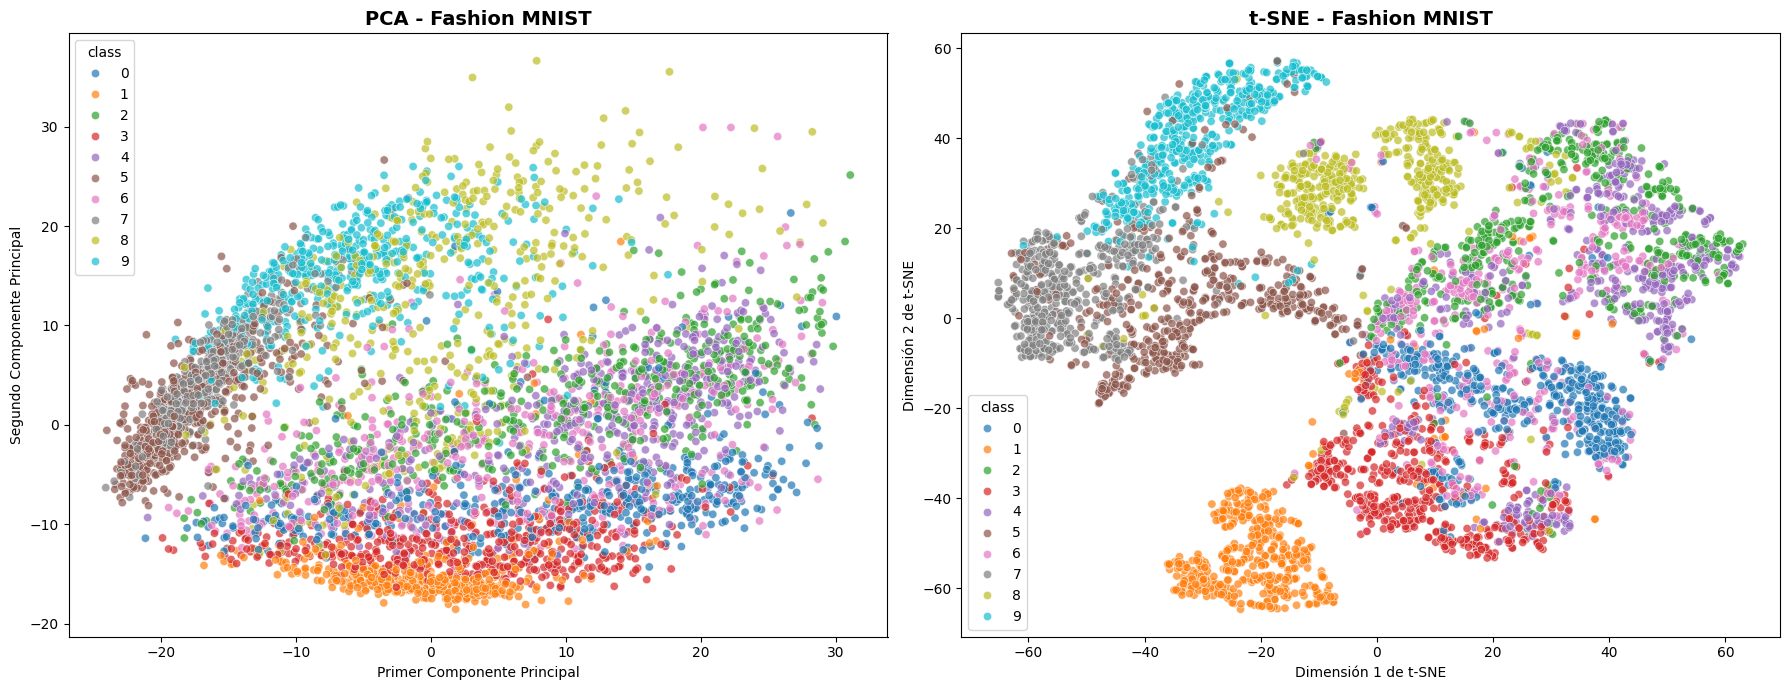

In [8]:
# 3. Crear la figura comparativa
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Subplot izquierdo: PCA
sns.scatterplot(
    x=X_sample_pca[:, 0], 
    y=X_sample_pca[:, 1], 
    hue=y_sample, 
    palette='tab10', 
    legend='full',
    ax=axes[0],
    alpha=0.7
)
axes[0].set_title('PCA - Fashion MNIST', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Primer Componente Principal')
axes[0].set_ylabel('Segundo Componente Principal')

# Subplot derecho: t-SNE
sns.scatterplot(
    x=X_sample_tsne[:, 0], 
    y=X_sample_tsne[:, 1], 
    hue=y_sample, 
    palette='tab10', 
    legend='full',
    ax=axes[1],
    alpha=0.7
)
axes[1].set_title('t-SNE - Fashion MNIST', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Dimensión 1 de t-SNE')
axes[1].set_ylabel('Dimensión 2 de t-SNE')

plt.tight_layout()
plt.show()


### Mis Reflexiones

*(Escribe aquí tus respuestas a las preguntas del reto para casa)*

# Ejercicio 2: El Restaurador de Imágenes (PCA para Denoising)

## Contexto
Trabajas en un archivo digital histórico. Tenéis miles de fotos de carnet antiguas que se han escaneado, pero el escáner ha introducido mucho "ruido" (grano, estática, puntos aleatorios).

Tu jefe te pregunta: *"¿Podemos usar esa IA de la que hablas para limpiar las fotos automáticamente?"*

## La Lógica
PCA busca los patrones más fuertes (la estructura de la cara: ojos, nariz, boca) y los guarda en los primeros componentes. El ruido, al ser aleatorio, suele quedarse en los últimos componentes (los menos importantes).

Si comprimimos la imagen y luego la **reconstruimos** usando **solo** los primeros componentes, recuperaremos la cara y dejaremos atrás el ruido.

## Tareas
1.  Cargaremos un dataset de caras reales.
2.  Añadiremos "ruido digital" artificialmente.
3.  **Tu misión:** Usar PCA para "comprimir" la imagen (quitar el ruido) y "descomprimirla" (recuperar la cara limpia).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.decomposition import PCA

# 1. CARGA DE DATOS (Lo hacemos por ti)
print("Cargando rostros...")
faces_data = fetch_olivetti_faces(shuffle=True, random_state=42)
X_faces = faces_data.data

# 2. SIMULACIÓN DE DAÑO (Añadir Ruido)
print("Dañando las imágenes con ruido digital...")
np.random.seed(42)
# Añadimos ruido aleatorio a cada pixel
X_noisy = X_faces + 0.05 * np.random.normal(size=X_faces.shape)


Cargando rostros...
Dañando las imágenes con ruido digital...


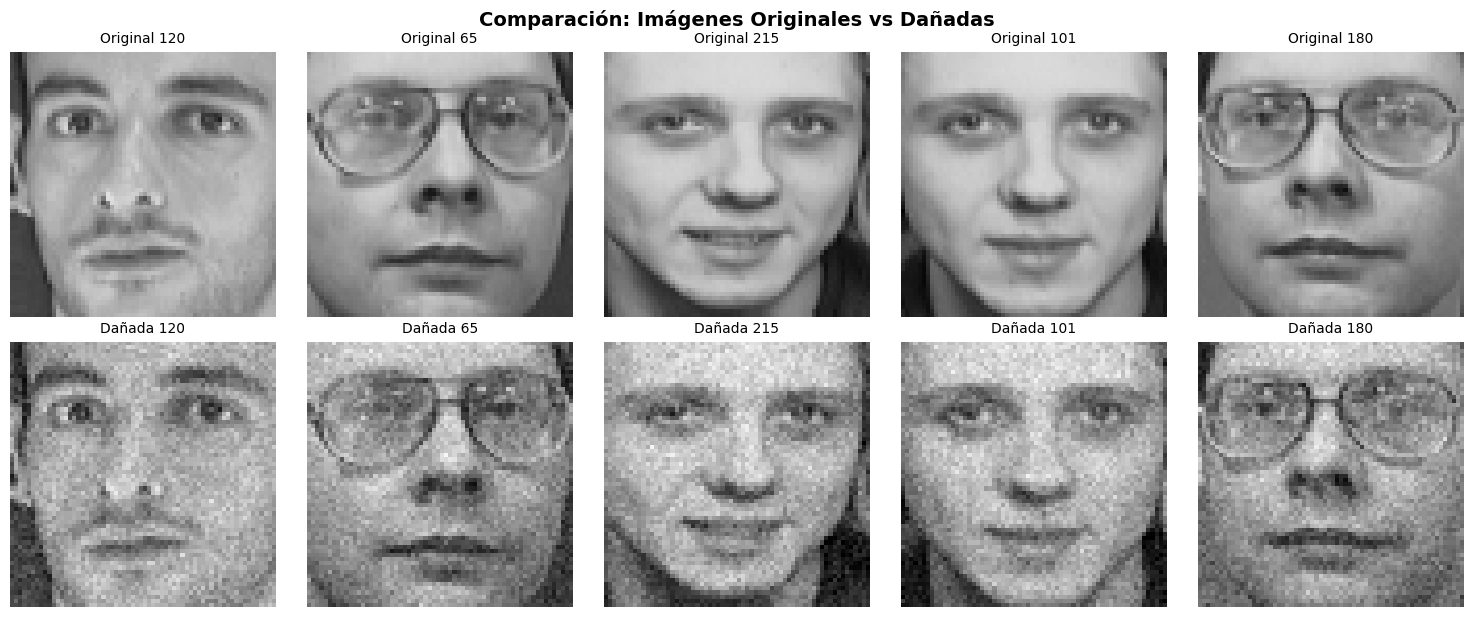

Mostrando 5 rostros originales y sus versiones con ruido digital


In [4]:
# Visualizar imágenes originales y dañadas
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

# Seleccionar 5 imágenes aleatorias para comparar
n_samples = 5
indices = np.random.choice(X_faces.shape[0], n_samples, replace=False)

# Mostrar imágenes originales (sin dañar)
for i, idx in enumerate(indices):
    axes[0, i].imshow(X_faces[idx].reshape(64, 64), cmap='gray', vmin=0, vmax=1)
    axes[0, i].axis('off')
    axes[0, i].set_title(f'Original {idx}', fontsize=10)

# Mostrar imágenes dañadas (con ruido)
for i, idx in enumerate(indices):
    axes[1, i].imshow(X_noisy[idx].reshape(64, 64), cmap='gray', vmin=0, vmax=1)
    axes[1, i].axis('off')
    axes[1, i].set_title(f'Dañada {idx}', fontsize=10)

axes[0, 0].set_ylabel('ORIGINALES', fontsize=12, weight='bold')
axes[1, 0].set_ylabel('DAÑADAS\n(con ruido)', fontsize=12, weight='bold')

plt.tight_layout()
plt.suptitle('Comparación: Imágenes Originales vs Dañadas', fontsize=14, weight='bold', y=1.02)
plt.show()

print(f"Mostrando {n_samples} rostros originales y sus versiones con ruido digital")

In [2]:

# 3. EL "RESTAURADOR" (PCA)
# 1. Instancia un PCA indicando n_components=0.50 
#    (Queremos conservar el 50% de la varianza/información, descartando el 50% restante que asumimos es ruido).
pca_restore = PCA(n_components=0.50, random_state=42)

# 2. Haz .fit() sobre las imágenes ruidosas (X_noisy).
pca_restore.fit(X_noisy)

print(f"PCA ajustado exitosamente.")
print(f"Componentes necesarios para conservar el 50% de la varianza: {pca_restore.n_components_}")


PCA ajustado exitosamente.
Componentes necesarios para conservar el 50% de la varianza: 6


In [3]:
# 4. PROCESO DE LIMPIEZA
# 1. Usa pca.transform() sobre X_noisy para comprimir la imagen (guardarlo en X_compressed)
X_compressed = pca_restore.transform(X_noisy)

# 2. Usa pca.inverse_transform() sobre X_compressed para reconstruirla (guardarlo en X_restored)
X_restored = pca_restore.inverse_transform(X_compressed)

print(f"Imágenes comprimidas: {X_compressed.shape}")
print(f"Imágenes restauradas: {X_restored.shape}")

Imágenes comprimidas: (400, 6)
Imágenes restauradas: (400, 4096)


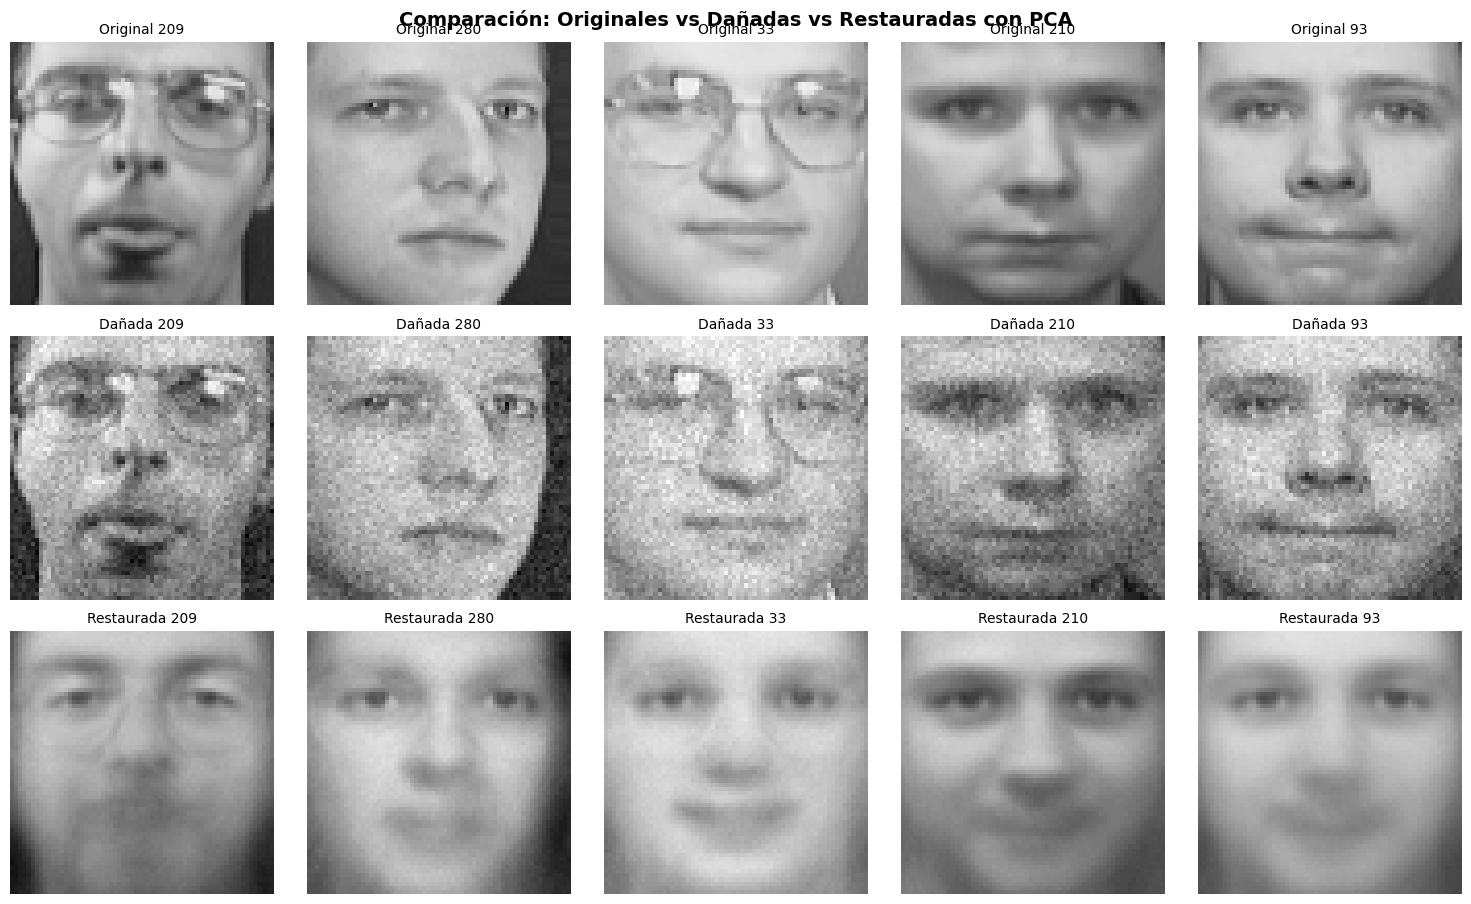


✅ Proceso completado: PCA ha restaurado las imágenes eliminando el ruido
   Componentes utilizados: 6 de 4096 originales
   Varianza conservada: 50%


In [4]:
# 5. VISUALIZACIÓN 
fig, axes = plt.subplots(3, 5, figsize=(15, 9))

# Seleccionar 5 imágenes aleatorias para comparar
n_samples = 5
np.random.seed(42)
indices = np.random.choice(X_faces.shape[0], n_samples, replace=False)

# Fila 1: Imágenes originales (sin dañar)
for i, idx in enumerate(indices):
    axes[0, i].imshow(X_faces[idx].reshape(64, 64), cmap='gray', vmin=0, vmax=1)
    axes[0, i].axis('off')
    axes[0, i].set_title(f'Original {idx}', fontsize=10)

# Fila 2: Imágenes dañadas (con ruido)
for i, idx in enumerate(indices):
    axes[1, i].imshow(X_noisy[idx].reshape(64, 64), cmap='gray', vmin=0, vmax=1)
    axes[1, i].axis('off')
    axes[1, i].set_title(f'Dañada {idx}', fontsize=10)

# Fila 3: Imágenes restauradas (limpiadas con PCA)
for i, idx in enumerate(indices):
    axes[2, i].imshow(X_restored[idx].reshape(64, 64), cmap='gray', vmin=0, vmax=1)
    axes[2, i].axis('off')
    axes[2, i].set_title(f'Restaurada {idx}', fontsize=10)

# Etiquetas de las filas
axes[0, 0].set_ylabel('ORIGINALES', fontsize=12, weight='bold')
axes[1, 0].set_ylabel('DAÑADAS\n(con ruido)', fontsize=12, weight='bold')
axes[2, 0].set_ylabel('RESTAURADAS\n(PCA 50%)', fontsize=12, weight='bold')

plt.tight_layout()
plt.suptitle('Comparación: Originales vs Dañadas vs Restauradas con PCA', fontsize=14, weight='bold', y=1.00)
plt.show()

print(f"\n✅ Proceso completado: PCA ha restaurado las imágenes eliminando el ruido")
print(f"   Componentes utilizados: {pca_restore.n_components_} de {X_faces.shape[1]} originales")
print(f"   Varianza conservada: 50%")

#  Ejercicio 3: Segmentación de Mercado en Alta Dimensión

## Contexto Real
Eres el Lead Data Scientist de un E-commerce de moda. Tienes una base de datos con **20 métricas diferentes** sobre el comportamiento de 1000 clientes:
* Gasto en diferentes categorías.
* Frecuencia de visitas web y tiempo en la app.
* Devoluciones, clics en ofertas, etc.

El equipo de Marketing quiere lanzar campañas personalizadas, pero **no saben quiénes son sus clientes**. Intentar analizar 20 columnas a la vez es imposible para un humano.

## El Reto (Pipeline Completo)
1.  **Reducir:** Usa PCA/t-SNE para comprimir esas 20 métricas y visualizar el mercado.
2.  **Clusterizar:** Aplica K-Means sobre los datos reducidos para etiquetar a los clientes.
3.  **Interpretar:** ¿Qué significa cada grupo? (Ej: "Los que gastan mucho y devuelven poco").

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification

# --- 1. GENERADOR DE DATOS "E-COMMERCE" (Ejecutar tal cual) ---
# Creamos datos complejos: 1000 clientes, 20 columnas. Hay 4 tipos de clientes ocultos.
X, y_true = make_classification(n_samples=1000, n_features=20, n_informative=10, 
                                n_redundant=5, n_clusters_per_class=1, 
                                n_classes=4, random_state=42)

# Ponemos nombres falsos a algunas columnas para dar contexto
cols = [f"Feature_{i}" for i in range(20)]
df = pd.DataFrame(X, columns=cols)
print("Datos de Marketing Generados: (1000 clientes, 20 métricas)")


# --- 2. PIPELINE DE REDUCCIÓN ---

# TU CÓDIGO AQUÍ:
# Paso A: Escalado (OBLIGATORIO siempre antes de PCA/t-SNE). 
# Crea un StandardScaler y transforma 'df'. Guarda el resultado en 'X_scaled'.


# Paso B: Reducción previa con PCA (Opcional pero recomendado para limpiar ruido)
# Reduce a 10 componentes primero.


# Paso C: Visualización con t-SNE

# Instancia TSNE con n_components=2 y random_state=42. Haz fit_transform sobre X_pca.



# --- 3. CLUSTERING (K-MEANS) ---
# Mira el gráfico mentalmente (o ejecútalo una vez para verlo). ¿Cuántos grupos ves?
# Pista: El generador de datos creó 4 grupos.

# TU CÓDIGO AQUÍ:
# 1. Instancia KMeans con n_clusters=4.
# 2. Entrena y predice (fit_predict) sobre 'X_tsne' (los datos reducidos).
# kmeans = None # ...
# clusters = None # ...

# --- 4. VISUALIZACIÓN FINAL  ---


Datos de Marketing Generados: (1000 clientes, 20 métricas)


#  Conclusiones y Estrategia de Negocio

Analiza la tabla de promedios (`df.groupby...`) y el gráfico.

### 1. El poder del "Pipeline"
Fíjate que K-Means por sí solo suele fallar con 20 o 50 columnas.
Al usar **t-SNE + K-Means**, hemos conseguido separar a los clientes en "islas" claras.

### 2. Estrategia (Interpretación)
Imagina que el **Grupo 0** tiene valores muy altos en `Feature_0` (digamos que es "Gasto Total") y bajos en `Feature_1` (digamos que es "Devoluciones").
* **Pregunta:** ¿Qué acción de marketing harías con este grupo? (¿Descuentos? ¿Club VIP? ¿Ignorarlos?)

Imagina que el **Grupo 2** gasta mucho pero devuelve casi todo.
* **Pregunta:** ¿Qué harías con ellos?